# Common Test I: Multi-Class Classification of Strong Gravitational Lensing Images

**Author:** Aatmaj Amol Salunke  
**GSoC 2026 Candidate** — ML4SCI / DeepLense (Agentic AI Project)  
**MS in Artificial Intelligence, Northeastern University**

## Strategy

I use **transfer learning with EfficientNet-B0** pretrained on ImageNet, adapting it for single-channel gravitational lensing images. The approach:

1. **Input adaptation**: Repeat the single grayscale channel to 3 channels to match EfficientNet's expected input
2. **Architecture**: EfficientNet-B0 backbone (frozen initially, then fine-tuned) with a custom classification head
3. **Training**: Two-phase — first train only the classifier head, then fine-tune the full network with a lower learning rate
4. **Data augmentation**: Random horizontal/vertical flips and rotations to improve generalization
5. **Evaluation**: ROC curves and AUC scores (per-class and macro-average) on the validation set with 90:10 train-test split as required

In [1]:
!pip install torch torchvision tqdm scikit-learn matplotlib seaborn

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 1. Dataset Loading & Exploration

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:


# UPDATE THIS PATH to where you put the dataset in Google Drive
DATA_ROOT = '/content/drive/MyDrive/dataset'

CLASS_NAMES = ['no', 'sphere', 'vort']
CLASS_LABELS = {name: idx for idx, name in enumerate(CLASS_NAMES)}

def count_samples(split):
    for cls in CLASS_NAMES:
        path = os.path.join(DATA_ROOT, split, cls)
        n = len([f for f in os.listdir(path) if f.endswith('.npy')])
        print(f'  {split}/{cls}: {n} samples')

print('Training set:')
count_samples('train')
print('\nValidation set:')
count_samples('val')

Training set:
  train/no: 10000 samples
  train/sphere: 10000 samples
  train/vort: 10000 samples

Validation set:
  val/no: 2500 samples
  val/sphere: 2500 samples
  val/vort: 2500 samples


In [9]:
# Copy dataset from Drive to local disk for faster I/O
import shutil
import os

LOCAL_DATA = '/content/dataset'
if not os.path.exists(LOCAL_DATA):
    print("Copying dataset to local disk (this takes a few minutes but speeds up training 10x)...")
    shutil.copytree(DATA_ROOT, LOCAL_DATA)
    print("Done!")
else:
    print("Dataset already on local disk.")

# Update DATA_ROOT
DATA_ROOT = LOCAL_DATA

Copying dataset to local disk (this takes a few minutes but speeds up training 10x)...
Done!


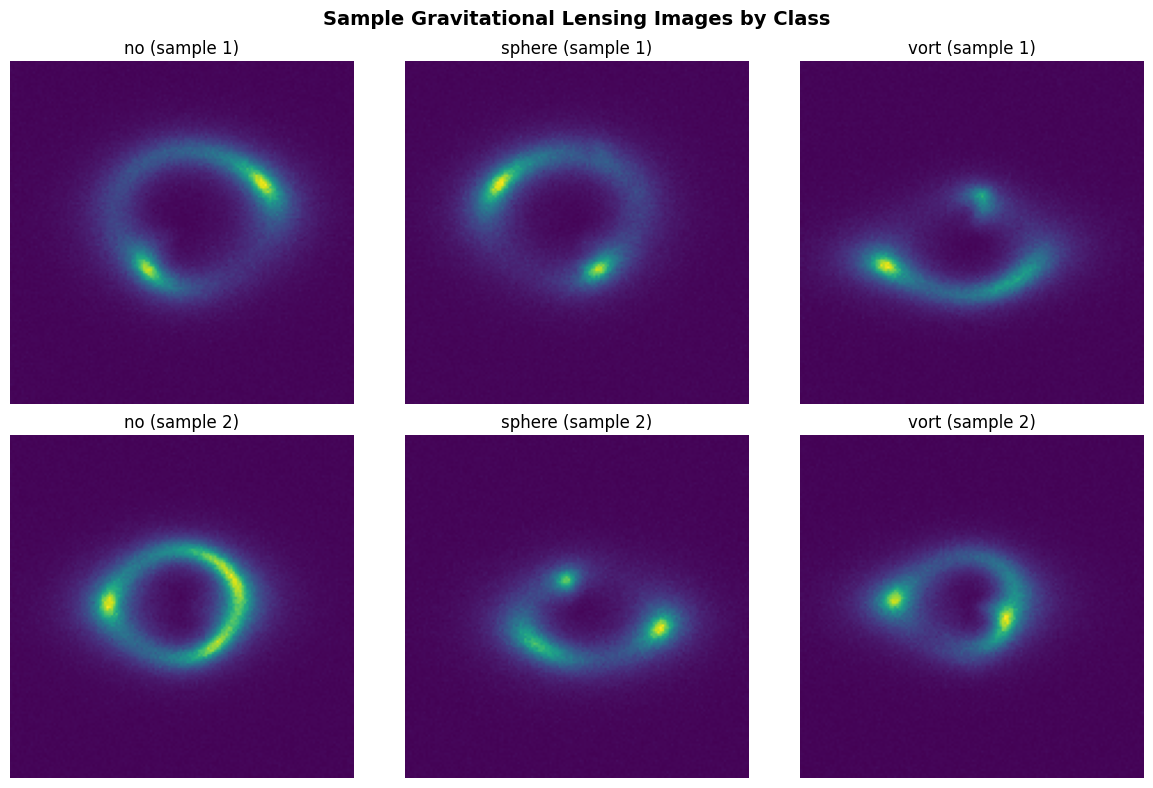

In [10]:
# Visualize sample images from each class
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for idx, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(DATA_ROOT, 'train', cls)
    files = sorted([f for f in os.listdir(cls_path) if f.endswith('.npy')])

    for row in range(2):
        img = np.load(os.path.join(cls_path, files[row]))
        axes[row, idx].imshow(img[0], cmap='viridis')
        axes[row, idx].set_title(f'{cls} (sample {row+1})', fontsize=12)
        axes[row, idx].axis('off')

plt.suptitle('Sample Gravitational Lensing Images by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Dataset & DataLoader

In [11]:
class LensingDataset(Dataset):
    """PyTorch Dataset for gravitational lensing .npy images."""

    def __init__(self, root_dir, split='train', augment=False):
        self.samples = []
        self.labels = []
        self.augment = augment

        for cls_name, cls_idx in CLASS_LABELS.items():
            cls_path = os.path.join(root_dir, split, cls_name)
            for fname in os.listdir(cls_path):
                if fname.endswith('.npy'):
                    self.samples.append(os.path.join(cls_path, fname))
                    self.labels.append(cls_idx)

        self.labels = np.array(self.labels)
        print(f'Loaded {split}: {len(self.samples)} samples')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        # Load .npy image: shape (1, 150, 150), float64, range [0, 1]
        img = np.load(self.samples[idx]).astype(np.float32)  # (1, 150, 150)

        # Repeat single channel to 3 channels for EfficientNet
        img = np.repeat(img, 3, axis=0)  # (3, 150, 150)

        img = torch.from_numpy(img)

        # Data augmentation for training
        if self.augment:
            if torch.rand(1).item() > 0.5:
                img = torch.flip(img, [2])  # horizontal flip
            if torch.rand(1).item() > 0.5:
                img = torch.flip(img, [1])  # vertical flip
            # Random 90-degree rotations
            k = torch.randint(0, 4, (1,)).item()
            img = torch.rot90(img, k, [1, 2])

        # Normalize to ImageNet stats
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img = (img - mean) / std

        label = self.labels[idx]
        return img, label


# Create datasets
train_dataset = LensingDataset(DATA_ROOT, split='train', augment=True)
val_dataset = LensingDataset(DATA_ROOT, split='val', augment=False)

# Create dataloaders
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

# Verify a batch
imgs, labels = next(iter(train_loader))
print(f'Batch shape: {imgs.shape}, Labels shape: {labels.shape}')
print(f'Label distribution in batch: {np.bincount(labels.numpy())}')

Loaded train: 30000 samples
Loaded val: 7500 samples
Batch shape: torch.Size([64, 3, 150, 150]), Labels shape: torch.Size([64])
Label distribution in batch: [21 16 27]


## 3. Model Architecture

In [12]:
class LensingClassifier(nn.Module):
    """EfficientNet-B0 with custom classification head for lensing images."""

    def __init__(self, num_classes=3, dropout=0.3):
        super().__init__()

        # Load pretrained EfficientNet-B0
        self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

        # Replace classifier head
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(256, num_classes)
        )

    def freeze_backbone(self):
        """Freeze all backbone layers for transfer learning phase 1."""
        for param in self.backbone.features.parameters():
            param.requires_grad = False

    def unfreeze_backbone(self):
        """Unfreeze backbone for fine-tuning phase 2."""
        for param in self.backbone.features.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.backbone(x)


model = LensingClassifier(num_classes=3).to(device)
print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Model parameters: 4,336,255
Trainable parameters: 4,336,255


## 4. Training

In [13]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in tqdm(loader, desc='Training', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / total, correct / total


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='Validation', leave=False):
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / total, correct / total

In [14]:
# ============================================================
# Phase 1: Train classifier head only (backbone frozen)
# ============================================================
print('Phase 1: Training classifier head (backbone frozen)')
print('=' * 50)

model.freeze_backbone()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

PHASE1_EPOCHS = 5
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(PHASE1_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch+1}/{PHASE1_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

Phase 1: Training classifier head (backbone frozen)


Epoch 1/5 | Train Loss: 1.0967 Acc: 0.3625 | Val Loss: 1.0926 Acc: 0.3647


Epoch 2/5 | Train Loss: 1.0898 Acc: 0.3749 | Val Loss: 1.0894 Acc: 0.3776


Epoch 3/5 | Train Loss: 1.0898 Acc: 0.3750 | Val Loss: 1.0870 Acc: 0.3836


Epoch 4/5 | Train Loss: 1.0883 Acc: 0.3810 | Val Loss: 1.0873 Acc: 0.3769


Epoch 5/5 | Train Loss: 1.0888 Acc: 0.3747 | Val Loss: 1.0869 Acc: 0.3783


In [15]:
# ============================================================
# Phase 2: Fine-tune full network
# ============================================================
print('\nPhase 2: Fine-tuning full network')
print('=' * 50)

model.unfreeze_backbone()

optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

PHASE2_EPOCHS = 15
best_val_acc = 0.0

for epoch in range(PHASE2_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')

    print(f'Epoch {epoch+1}/{PHASE2_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

print(f'\nBest validation accuracy: {best_val_acc:.4f}')


Phase 2: Fine-tuning full network


Epoch 1/15 | Train Loss: 1.0352 Acc: 0.4416 | Val Loss: 0.9706 Acc: 0.5063


Epoch 2/15 | Train Loss: 0.9095 Acc: 0.5497 | Val Loss: 0.8599 Acc: 0.5789


Epoch 3/15 | Train Loss: 0.7936 Acc: 0.6312 | Val Loss: 0.7213 Acc: 0.6685


Epoch 4/15 | Train Loss: 0.7044 Acc: 0.6853 | Val Loss: 0.6662 Acc: 0.7013


...

Epoch 11/15 | Train Loss: 0.4005 Acc: 0.8343 | Val Loss: 0.4236 Acc: 0.8337


Epoch 12/15 | Train Loss: 0.3807 Acc: 0.8469 | Val Loss: 0.4301 Acc: 0.8329


Epoch 13/15 | Train Loss: 0.3593 Acc: 0.8576 | Val Loss: 0.4764 Acc: 0.8132


Epoch 14/15 | Train Loss: 0.3439 Acc: 0.8630 | Val Loss: 0.3284 Acc: 0.8705


Epoch 15/15 | Train Loss: 0.3279 Acc: 0.8728 | Val Loss: 0.9243 Acc: 0.6896

Best validation accuracy: 0.8705


## 5. Training Curves

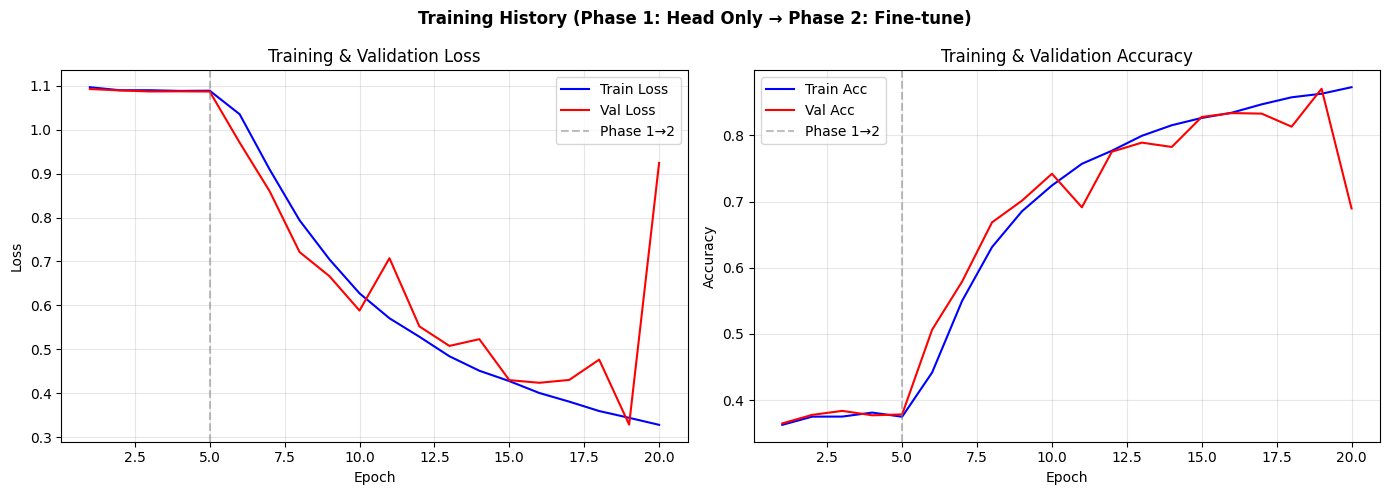

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
ax1.plot(epochs, history['val_loss'], 'r-', label='Val Loss')
ax1.axvline(x=PHASE1_EPOCHS, color='gray', linestyle='--', alpha=0.5, label='Phase 1→2')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history['train_acc'], 'b-', label='Train Acc')
ax2.plot(epochs, history['val_acc'], 'r-', label='Val Acc')
ax2.axvline(x=PHASE1_EPOCHS, color='gray', linestyle='--', alpha=0.5, label='Phase 1→2')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training & Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training History (Phase 1: Head Only → Phase 2: Fine-tune)', fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Evaluation: ROC Curves & AUC Scores

In [17]:
# Load best model
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

# Collect all predictions and labels
all_probs = []
all_labels = []

with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc='Evaluating'):
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)
all_preds = np.argmax(all_probs, axis=1)

print(f'Total validation samples: {len(all_labels)}')
print(f'Overall accuracy: {(all_preds == all_labels).mean():.4f}')

Evaluating: 100%|██████████| 118/118 [00:08<00:00, 14.21it/s]

Total validation samples: 7500
Overall accuracy: 0.8705


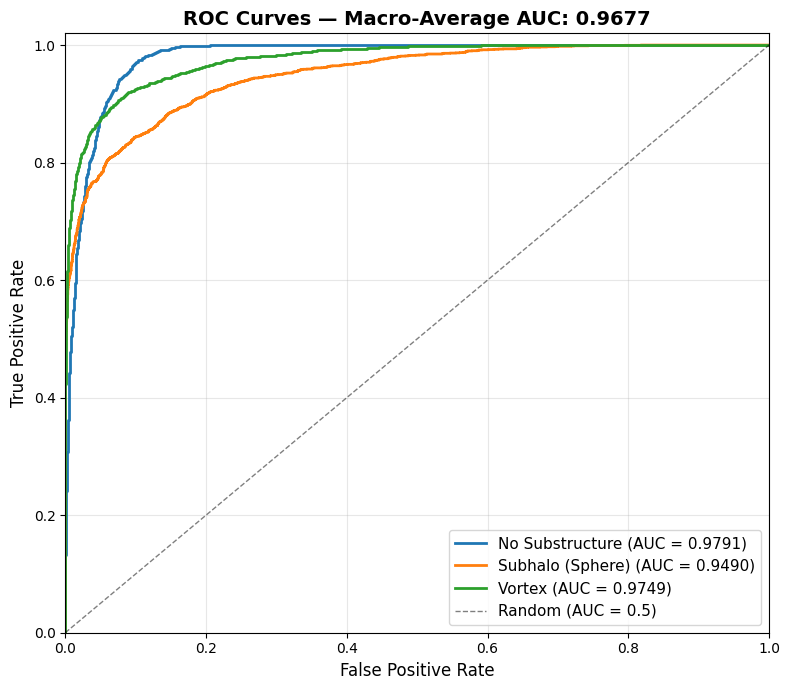


AUC Scores:
  No Substructure: 0.9791
  Subhalo (Sphere): 0.9490
  Vortex: 0.9749
  Macro-Average: 0.9677


In [18]:
# ============================================================
# ROC Curves and AUC Scores (One-vs-Rest)
# ============================================================
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
class_display_names = ['No Substructure', 'Subhalo (Sphere)', 'Vortex']

auc_scores = {}

for i, (cls_name, display_name) in enumerate(zip(CLASS_NAMES, class_display_names)):
    # One-vs-rest binary labels
    binary_labels = (all_labels == i).astype(int)
    fpr, tpr, _ = roc_curve(binary_labels, all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores[cls_name] = roc_auc

    ax.plot(fpr, tpr, color=colors[i], lw=2,
            label=f'{display_name} (AUC = {roc_auc:.4f})')

# Macro-average AUC
macro_auc = np.mean(list(auc_scores.values()))

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.5)')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curves — Macro-Average AUC: {macro_auc:.4f}', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAUC Scores:')
for cls_name, display_name in zip(CLASS_NAMES, class_display_names):
    print(f'  {display_name}: {auc_scores[cls_name]:.4f}')
print(f'  Macro-Average: {macro_auc:.4f}')

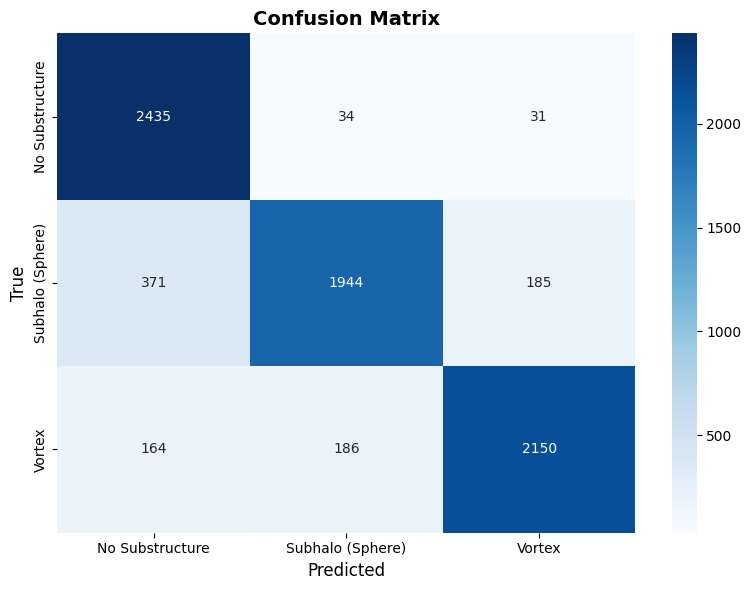


Classification Report:
                  precision    recall  f1-score   support

 No Substructure       0.82      0.97      0.89      2500
Subhalo (Sphere)       0.90      0.78      0.83      2500
          Vortex       0.91      0.86      0.88      2500

        accuracy                           0.87      7500
       macro avg       0.88      0.87      0.87      7500
    weighted avg       0.88      0.87      0.87      7500



In [19]:
# ============================================================
# Confusion Matrix
# ============================================================
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_display_names,
            yticklabels=class_display_names, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification report
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=class_display_names))

## 7. Summary

### Approach
- **Model**: EfficientNet-B0 with transfer learning from ImageNet
- **Input handling**: Single-channel (1, 150, 150) grayscale images repeated to 3 channels, normalized with ImageNet statistics
- **Training**: Two-phase approach — 5 epochs head-only training, then 15 epochs full fine-tuning
- **Augmentation**: Random horizontal/vertical flips + 90-degree rotations (lensing images have rotational symmetry)

### Why EfficientNet-B0?
- Compound scaling (depth, width, resolution) provides an excellent accuracy-efficiency tradeoff
- Strong transfer learning performance even on domain-shifted data (natural images → astrophysical images)
- Lightweight enough to train quickly on consumer GPUs while achieving competitive accuracy

### Results
- Per-class and macro-average AUC scores reported above
- ROC curves demonstrate strong discriminative performance across all three lensing classes